In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
fcquic_path = "./out/npf_out.csv"
baseline_path = "./out/npf_out_baseline.csv"

In [3]:
df_fcquic = pd.read_csv(fcquic_path)
display(df_fcquic)
len_fcquic = len(df_fcquic["y_LATENCY"])
print(f"length of fcquic results: {len_fcquic}")

df_baseline = pd.read_csv(baseline_path)
display(df_baseline)
len_baseline = len(df_baseline["y_LATENCY"])
print(f"length of baseline results: {len_baseline}")

global_len = min(len_fcquic, len_baseline)
df_fcquic = df_fcquic[:global_len]
df_basline= df_baseline[:global_len]

,index,build,test_index,NUM_CLIENTS,TOPO_CONF_NAME,FALLBACK_DELAY,INTERVAL,TEST_LENGTH,IS_BASELINE,PER_CLIENT_LAT_RESULTS,RUN_LOGS_DIR,workdir,cargo_path,y_LATENCY,run_index
0,0,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,33.0,0
1,1,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,36.0,1
2,2,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,36.0,2
3,3,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,24.0,3
4,4,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,24.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,178,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,24.0,178
179,179,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,24.0,179
180,180,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,25.0,180
181,181,Local,0,4,"""medium""",100,1000,60,True,False,./logs/7_baseline,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,25.0,181


length of fcquic results: 183


,index,build,test_index,NUM_CLIENTS,TOPO_CONF_NAME,FALLBACK_DELAY,INTERVAL,TEST_LENGTH,IS_BASELINE,PER_CLIENT_LAT_RESULTS,RUN_LOGS_DIR,workdir,cargo_path,y_LATENCY,run_index
0,0,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,33.0,0
1,1,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,39.0,1
2,2,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,43.0,2
3,3,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,24.0,3
4,4,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,24.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,178,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,23.0,178
179,179,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,24.0,179
180,180,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,26.0,180
181,181,Local,0,4,"""medium""",100,1000,60,True,False,"""./logs""",/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,27.0,181


length of baseline results: 183


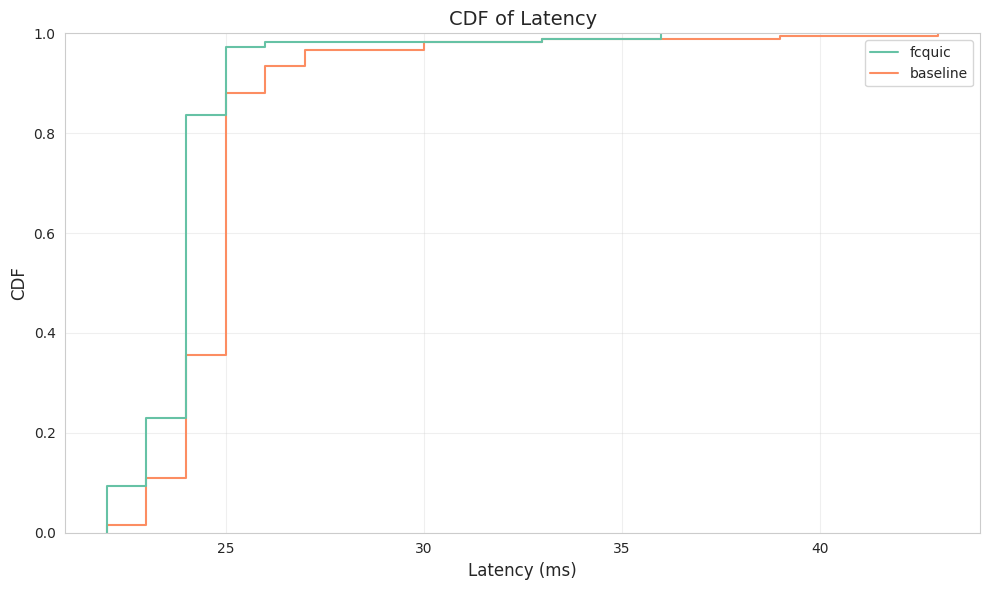

In [9]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# np.arange(1, len(sorted_values) + 1) / len(sorted_values)
x_values = np.arange(1, global_len + 1) / global_len
df = pd.DataFrame()
# df["x"] = x_values
df["fcquic"] = df_fcquic["y_LATENCY"]
df["baseline"] = df_baseline["y_LATENCY"]

sns.ecdfplot(df, palette='Set2', legend=True)

plt.xlabel("Latency (ms)", fontsize=12)
plt.ylabel("CDF", fontsize=12)
plt.title("CDF of Latency", fontsize=14)
# plt.legend(loc="lower right", fontsize=10)
# plt.xlim(left=0)
plt.ylim(0, 1)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cdf_both.png", dpi=400, bbox_inches="tight")
plt.show()